<a href="https://colab.research.google.com/github/gvp2ms/A02-eda-and-visualization/blob/main/a02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

Index(['ID', 'OPEID', 'Institution Name', 'City', 'State',
       'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type',
       'Country of Giftor', 'Giftor Name'],
      dtype='object')



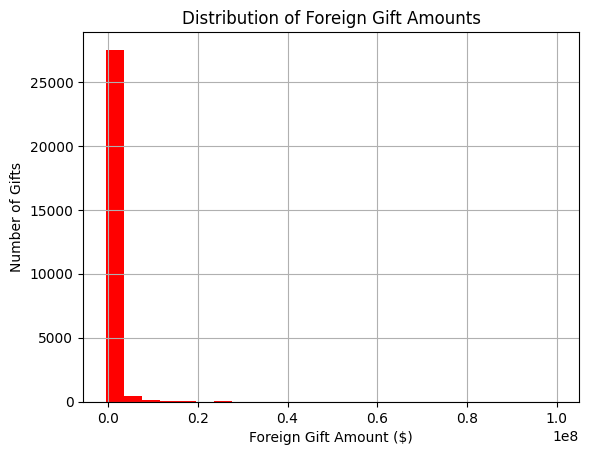

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64
The mean is  588232.7172672832
The median is  94615.0
The standard deviation is  3222011.4279505583
The variance is  10381357641843.994

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
As seen by the table, the proportion of gifts that are contracts is 0.612097, 
those that are monetary gifts is 0.387513, and those that are real estate are 0.0000390



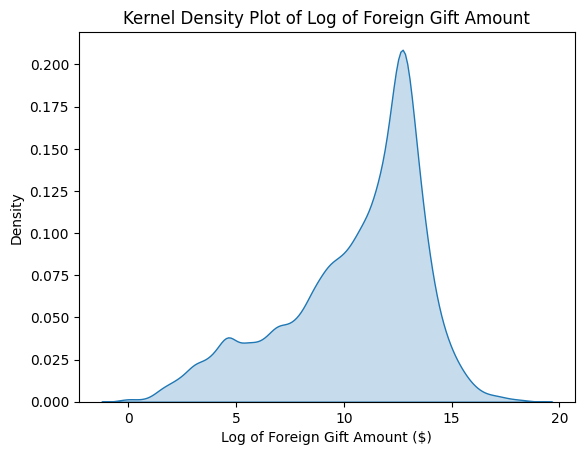

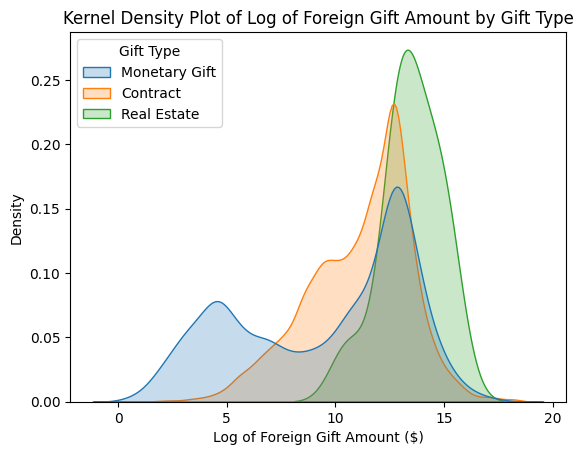

A pattern that I noticed is that the graph of the log of Foreign Gift Amount looks very similar to the graph of the three conditionals combined.
 Both contracts and monetary gifts have a peak around the same place as the log of Foreign Gift Amounts.
Top 15 countries in terms of the number of gifts:
Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: count, dtype: int64

Top 15 countries in terms of the amount given:
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG           

In [33]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#import dataset
df = pd.read_csv('ForeignGifts_edu.csv')
print(df.columns)
print()

#2 For Foreign Gift Amount, create a histogram and describe the variable. Describe your findings.
df['Foreign Gift Amount'].hist(color = 'red', bins=25)
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Number of Gifts")
plt.title("Distribution of Foreign Gift Amounts")
plt.show()
print(df['Foreign Gift Amount'].describe())
print("The mean is ", df['Foreign Gift Amount'].mean())
print("The median is ", df['Foreign Gift Amount'].median())
print("The standard deviation is ", df['Foreign Gift Amount'].std())
print("The variance is ", df['Foreign Gift Amount'].var())
print()

#3 For Gift Type, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
print(df['Gift Type'].value_counts(normalize=True))
print("As seen by the table, the proportion of gifts that are contracts is 0.612097, \nthose that are monetary gifts is 0.387513, and those that are real estate are 0.0000390")
print()

#4 Create a kernel density plot of the log of Foreign Gift Amount, and then a kernel density plot of the log of Foreign Gift Amount conditional on gift type. Do you notice any patterns?

fga_clean = df[df['Foreign Gift Amount'] > 0].copy()
fga_clean['Log_Gift_Amount'] = np.log1p(fga_clean['Foreign Gift Amount'])
sns.kdeplot(fga_log, fill=True, common_norm = True)
plt.xlabel("Log of Foreign Gift Amount ($)")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Log of Foreign Gift Amount")
plt.show()
print()

sns.kdeplot(data = fga_clean, x='Log_Gift_Amount', hue='Gift Type', fill=True, common_norm = False)

plt.xlabel("Log of Foreign Gift Amount ($)")
plt.ylabel("Density")
plt.title("Kernel Density Plot of Log of Foreign Gift Amount by Gift Type")
plt.show()

print("A pattern that I noticed is that the graph of the log of Foreign Gift Amount looks very similar to the graph of the three conditionals combined.\n Both contracts and monetary gifts have a peak around the same place as the log of Foreign Gift Amounts.")
print()

#5 What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
top_num = df['Country of Giftor'].value_counts().head(15)
print("Top 15 countries in terms of the number of gifts:")
print(top_num)
print()

top_amt = df.groupby('Country of Giftor') ['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)
print("Top 15 countries in terms of the amount given:")
print(top_amt)
print()

#6 Which giftors provide the most money, in total?
df_most_money = df.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
print("The giftors that provide the most money are: \n", df_most_money.head(15))




## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]